# Exploratory Data Analysis (EDA) of Thai Constitution Data

In [ ]:
import ast
import itertools
from collections import Counter

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from tqdm import tqdm

tqdm.pandas()

sns.set_theme(style='whitegrid')

font_path = '../../static/font/LINESeedSansTH_Rg.ttf'
fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

## 1. Data Loading and Cleaning

In [58]:
df = pd.read_csv("../../data/preprocessed_data.csv")
df['tokens'] = df['tokens'].apply(ast.literal_eval)
df['tokens']

0       [สยาม, ประเทศ, ราชอาณาจักร, แบ่งแยก, ประชาชน, ...
1       [อำนาจ, อธิปไตย, ปวง, ชน, สยาม, พระมหากษัตริย์...
2       [องค์, พระมหากษัตริย์, ดำรง, ฐานะ, เคารพ, สัก,...
3            [พระมหากษัตริย์, พุทธมามกะ, อัครศาสนูปถัมภก]
4           [พระมหากษัตริย์, ดำรง, ตำแหน่ง, จอมทัพ, สยาม]
                              ...                        
4701                                  [วาระ, บท, บัญญัติ]
4702                                                   []
4703    [รัฐธรรมนูญ, ราชอาณาจักรไทย, รัฐธรรมนูญ, บังคั...
4704                                                   []
4705    [รัฐธรรมนูญ, ราชอาณาจักรไทย, สภาผู้แทนราษฎร, ส...
Name: tokens, Length: 4706, dtype: object

In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4706 entries, 0 to 4705
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   constitution_id  4706 non-null   str   
 1   year_th          4706 non-null   int64 
 2   name_short       4706 non-null   str   
 3   chapter_number   4706 non-null   int64 
 4   section_number   4706 non-null   int64 
 5   text             4706 non-null   str   
 6   tokens           4706 non-null   object
 7   word_count       4706 non-null   int64 
dtypes: int64(4), object(1), str(3)
memory usage: 294.3+ KB


In [61]:
df.drop(columns=["tokens"]).nunique()

constitution_id      38
year_th              31
name_short           38
chapter_number       18
section_number      336
text               3995
word_count          170
dtype: int64

In [ ]:
df

,constitution_id,year_th,name_short,chapter_number,section_number,text,tokens,word_count
0,const_2475,2475,2475,0,1,สยามประเทศเป็นราชอาณาจักรอันหนึ่งอันเดียว จะแบ...,"['สยาม', 'ประเทศ', 'ราชอาณาจักร', 'แบ่งแยก', '...",12
1,const_2475,2475,2475,0,2,อำนาจอธิปไตยย่อมมาจากปวงชนชาวสยาม พระมหากษัตริ...,"['อำนาจ', 'อธิปไตย', 'ปวง', 'ชน', 'สยาม', 'พระ...",11
2,const_2475,2475,2475,1,3,องค์พระมหากษัตริย์ดำรงอยู่ในฐานะอันเป็นที่เคาร...,"['องค์', 'พระมหากษัตริย์', 'ดำรง', 'ฐานะ', 'เค...",8
3,const_2475,2475,2475,1,4,พระมหากษัตริย์ต้องทรงเป็นพุทธมามกะ และทรงเป็นอ...,"['พระมหากษัตริย์', 'พุทธมามกะ', 'อัครศาสนูปถัม...",3
4,const_2475,2475,2475,1,5,พระมหากษัตริย์ทรงดำรงตำแหน่งจอมทัพ สยาม,"['พระมหากษัตริย์', 'ดำรง', 'ตำแหน่ง', 'จอมทัพ'...",5
...,...,...,...,...,...,...,...,...
4701,const_2564,2564,2564,0,6,ในวาระเริ่มแรก มิให้นำบทบัญญัติ,"['วาระ', 'บท', 'บัญญัติ']",3
4702,const_2564,2564,2564,0,86,และ,[],0
4703,const_2564,2564,2564,0,91,ของรัฐธรรมนูญแห่งราชอาณาจักรไทย ซึ่งแก้ไขเพิ่ม...,"['รัฐธรรมนูญ', 'ราชอาณาจักรไทย', 'รัฐธรรมนูญ',...",51
4704,const_2564,2564,2564,0,83,และ,[],0


In [ ]:
df['has_parentheses'] = df['name_short'].str.contains(r'\(.*?\)')
df[df['has_parentheses']]["name_short"].unique()

<StringArray>
['2490 (interim)', '2490 (amended)',    '2491 (No.2)',    '2491 (No.3)',
 '2534 (interim)',    '2535 (No.1)',    '2535 (No.2)',    '2535 (No.3)',
    '2535 (No.4)', '2549 (interim)',    '2554 (No.1)',    '2554 (No.2)',
 '2557 (interim)']
Length: 13, dtype: str

## 2. Basic Structural EDA

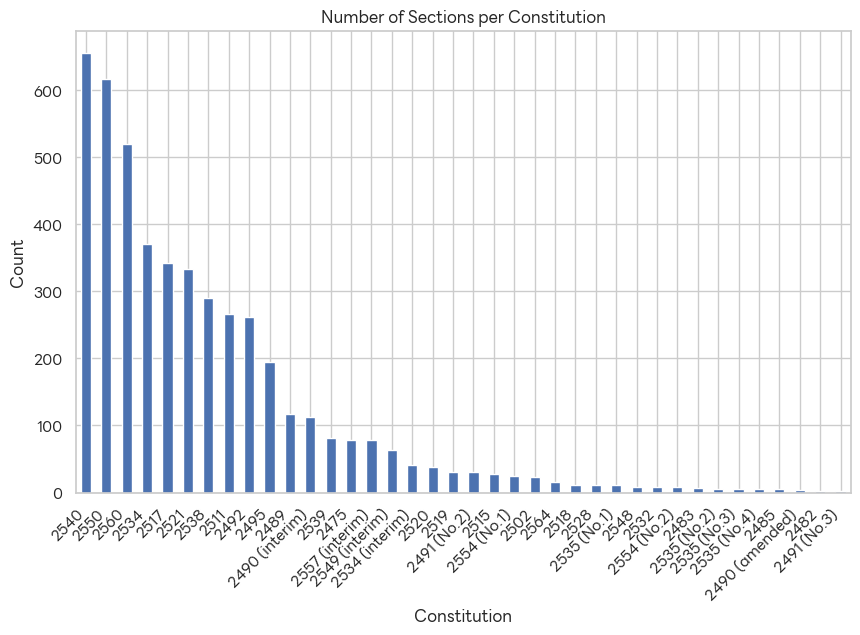

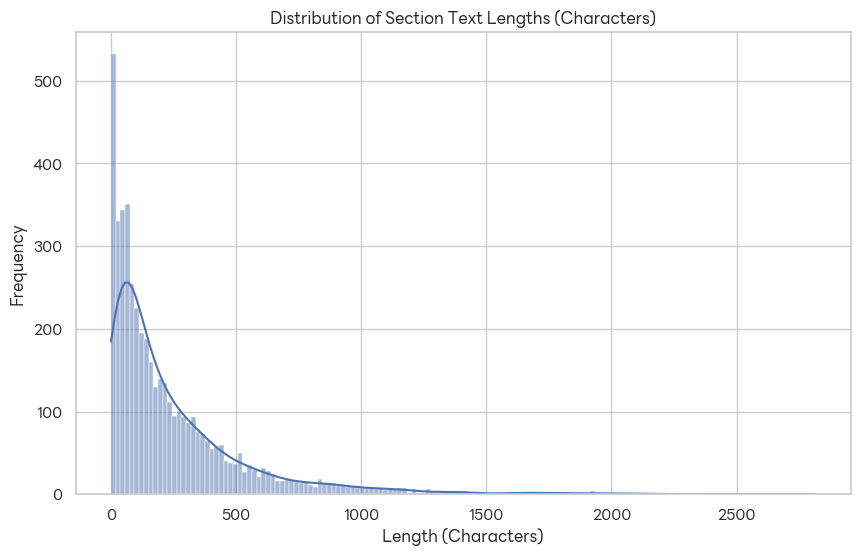

In [ ]:
sections_per_const = df.groupby('name_short').size().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sections_per_const.plot(kind='bar')
plt.title('Number of Sections per Constitution')
plt.xlabel('Constitution')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

# Text Length Distribution
df['text_length'] = df['text'].str.len()
plt.figure(figsize=(10, 6))
sns.histplot(df['text_length'], bins=150, kde=True)
plt.title('Distribution of Section Text Lengths (Characters)')
plt.xlabel('Length (Characters)')
plt.ylabel('Frequency')
plt.show()

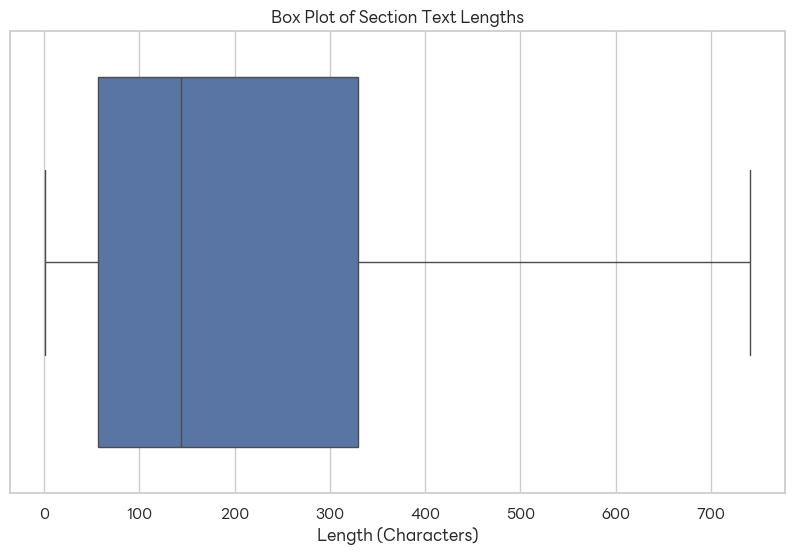

In [47]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['text_length'], showfliers=False)
plt.title('Box Plot of Section Text Lengths')
plt.xlabel('Length (Characters)')
plt.show()

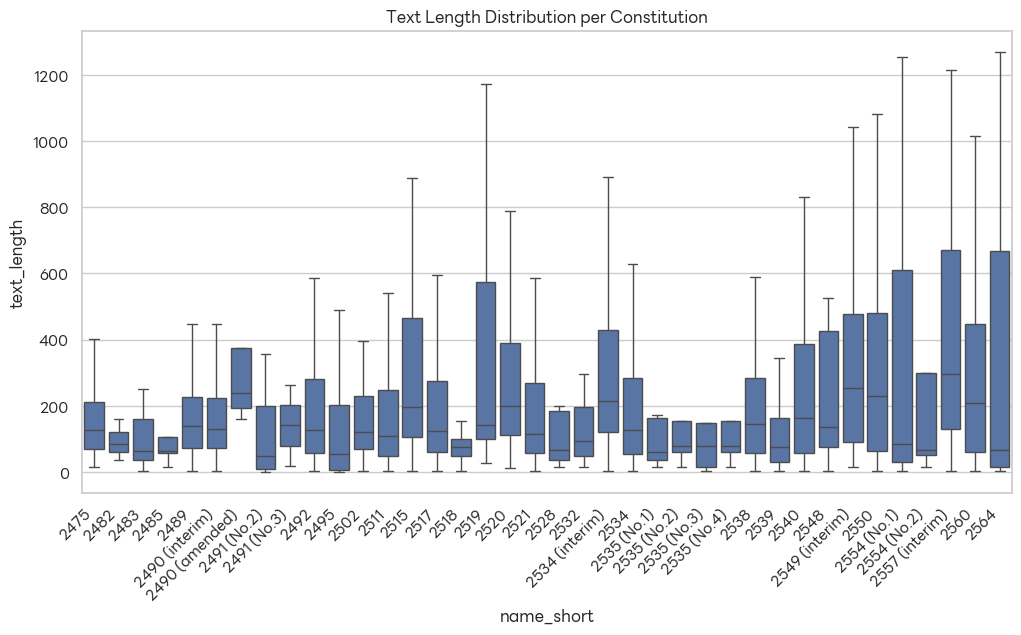

In [40]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='name_short', y='text_length', data=df, showfliers=False)
plt.title('Text Length Distribution per Constitution')
plt.xticks(rotation=45, ha='right')
plt.show()

## 3. Thai Tokenization and Preprocessing

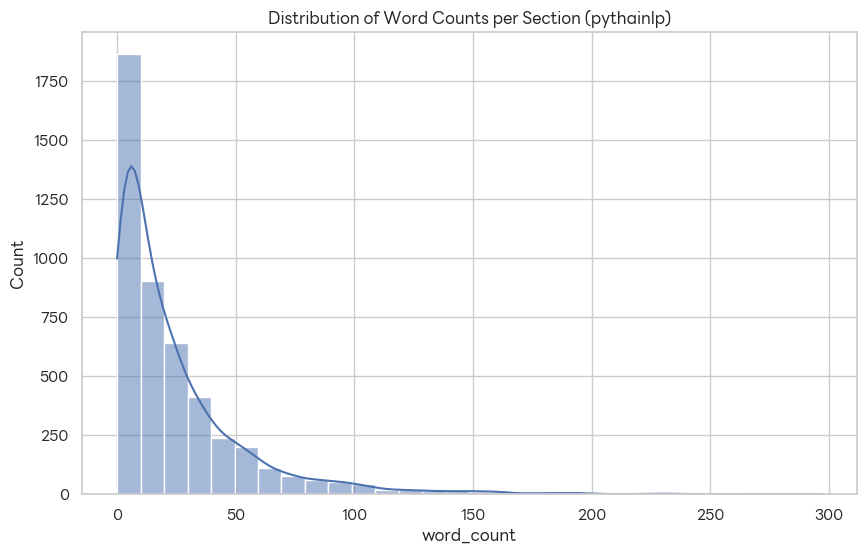

In [21]:
# Visualize Word Counts
plt.figure(figsize=(10, 6))
sns.histplot(df['word_count'].dropna(), bins=30, kde=True)
plt.title('Distribution of Word Counts per Section (pythainlp)')
plt.show()

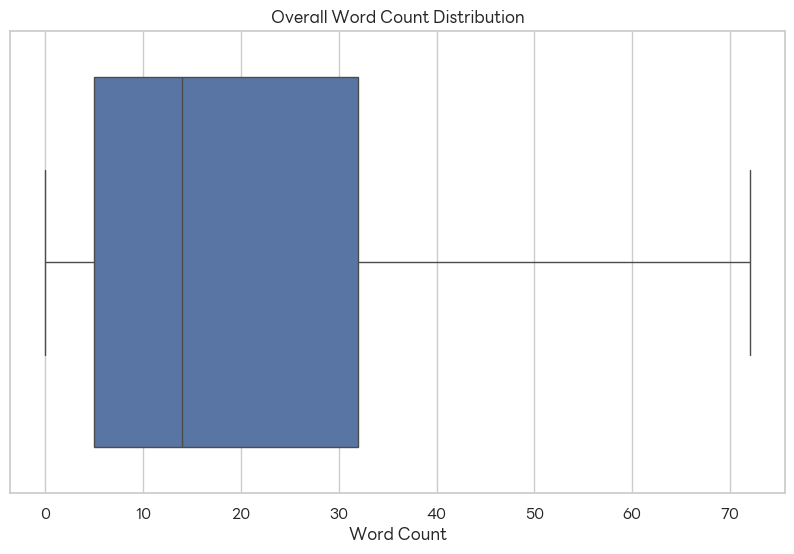

In [50]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['word_count'], showfliers=False)
plt.title('Overall Word Count Distribution')
plt.xlabel('Word Count')
plt.show()

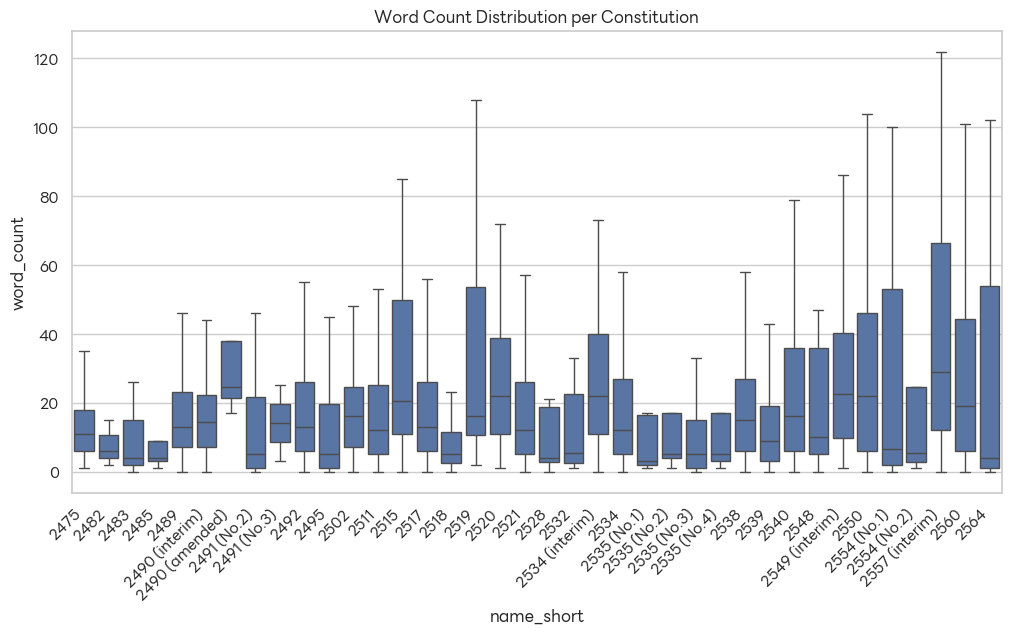

In [46]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='name_short', y='word_count', data=df, showfliers=False)
plt.title('Word Count Distribution per Constitution')
plt.xticks(rotation=45, ha='right')
plt.show()

## 4. Bag-of-Words (BoW) Analysis

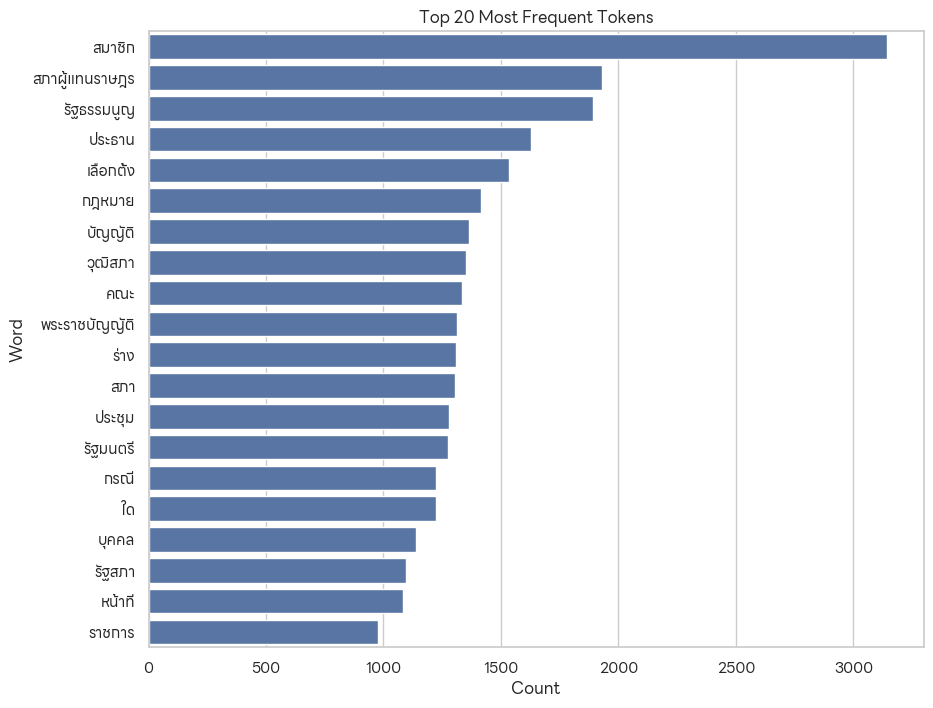

In [22]:
all_tokens = list(itertools.chain.from_iterable(df['tokens'].dropna()))
token_counts = Counter(all_tokens)

top_bow_df = pd.DataFrame(token_counts.most_common(20), columns=['Word', 'Count'])

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Count', y='Word', data=top_bow_df)
plt.title('Top 20 Most Frequent Tokens')
plt.show()

## 5. N-Gram Analysis

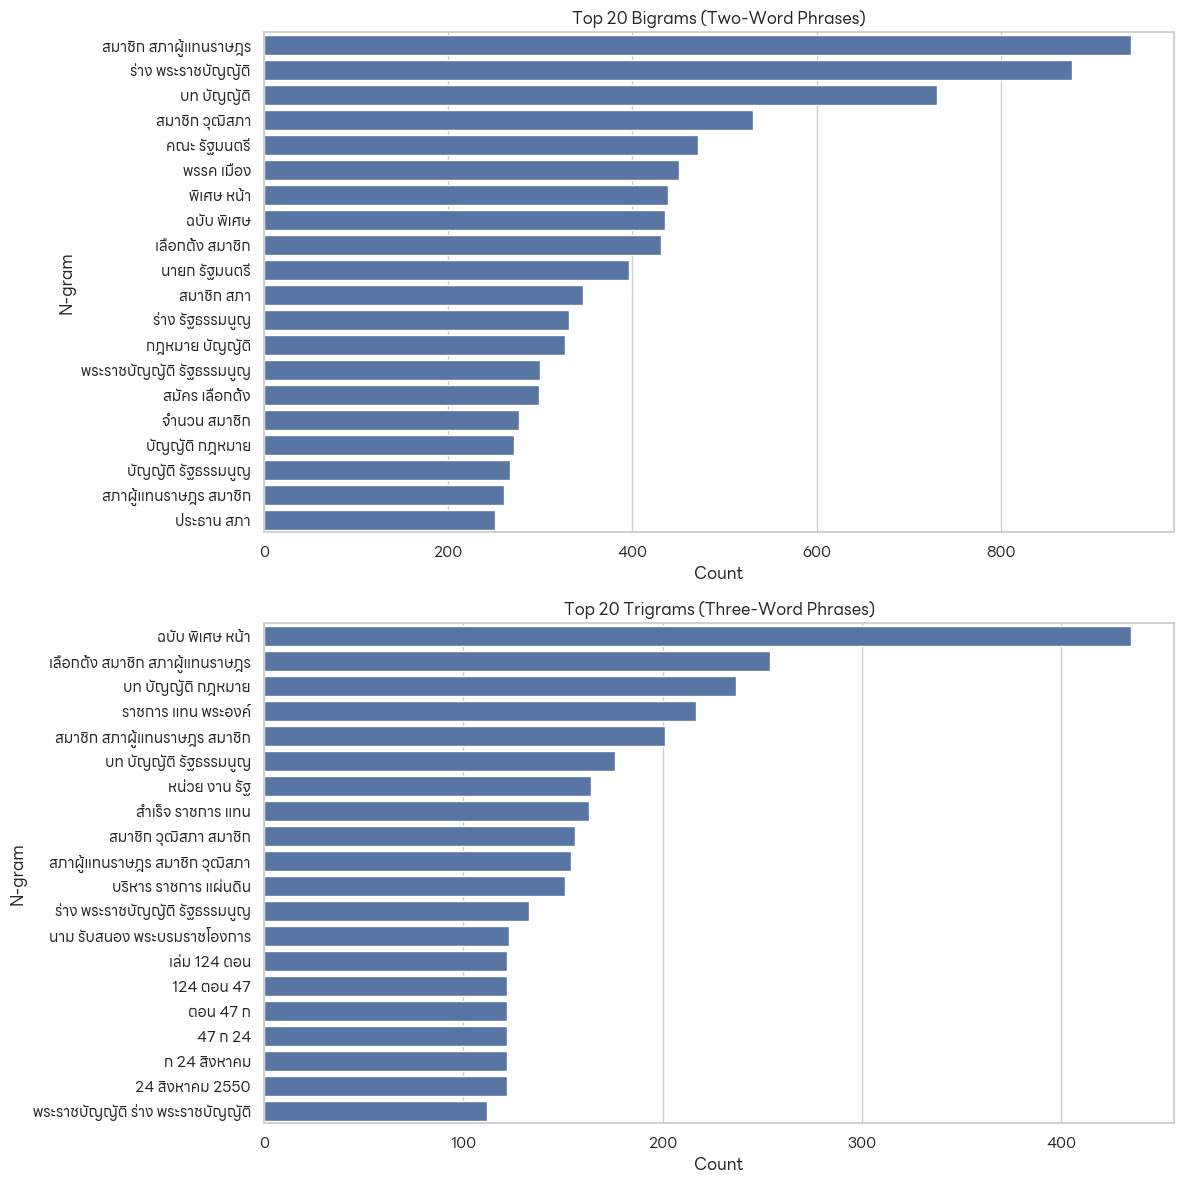

In [23]:
def get_top_ngrams(corpus, n=None, top_k=20):
    flat_list = [item for sublist in corpus.dropna() for item in sublist]
    ngrams_list = [' '.join(flat_list[i:i+n]) for i in range(len(flat_list)-n+1)]
    return Counter(ngrams_list).most_common(top_k)

# Get top 20 bigrams
top_20_bigrams = get_top_ngrams(df['tokens'], n=2, top_k=20)
top_20_bigrams_df = pd.DataFrame(top_20_bigrams, columns=['N-gram', 'Count'])

# Get top 20 trigrams
top_20_trigrams = get_top_ngrams(df['tokens'], n=3, top_k=20)
top_20_trigrams_df = pd.DataFrame(top_20_trigrams, columns=['N-gram', 'Count'])

# Plot
plt.figure(figsize=(12, 12))

plt.subplot(2, 1, 1)
sns.barplot(x='Count', y='N-gram', data=top_20_bigrams_df)
plt.title('Top 20 Bigrams (Two-Word Phrases)')

plt.subplot(2, 1, 2)
sns.barplot(x='Count', y='N-gram', data=top_20_trigrams_df)
plt.title('Top 20 Trigrams (Three-Word Phrases)')

plt.tight_layout()
plt.show()

## 6. TF-IDF Analysis

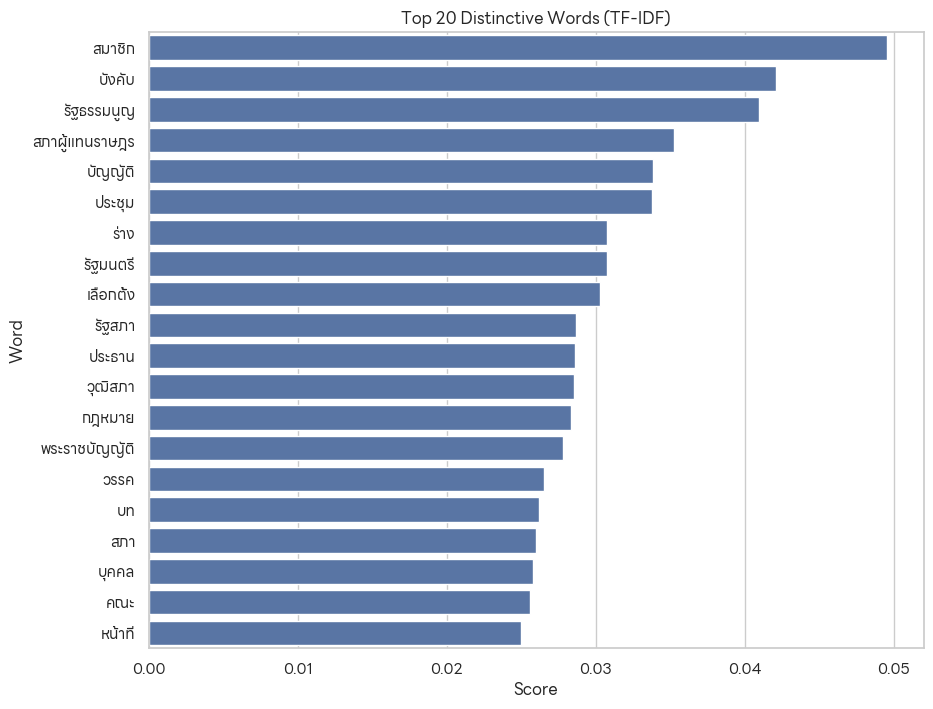

In [24]:
df_tfidf = df.dropna(subset=['tokens']).copy()

# Vectorization
vectorizer = TfidfVectorizer(
    tokenizer=lambda x: x,
    preprocessor=lambda x: x,
    token_pattern=None
)
tfidf_matrix = vectorizer.fit_transform(df_tfidf['tokens'])
feature_names = vectorizer.get_feature_names_out()

feature_names = vectorizer.get_feature_names_out()

def get_top_tfidf_words(matrix, feature_names, top_n=10):
    mean_scores = np.asarray(matrix.mean(axis=0)).flatten()
    top_indices = mean_scores.argsort()[-top_n:][::-1]
    return [(feature_names[i], mean_scores[i]) for i in top_indices]

top_keywords = get_top_tfidf_words(tfidf_matrix, feature_names, top_n=20)
top_keywords_df = pd.DataFrame(top_keywords, columns=['Word', 'Score'])

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Score', y='Word', data=top_keywords_df)
plt.title('Top 20 Distinctive Words (TF-IDF)')
plt.show()

In [25]:
import ipywidgets as widgets
from IPython.display import display


# Function to compute and plot TF-IDF n-grams
def plot_tfidf_ngrams(n=2, top_n=20):
    vectorizer = TfidfVectorizer(
        tokenizer=lambda x: x,
        preprocessor=lambda x: x,
        token_pattern=None,
        ngram_range=(n, n),
        min_df=2  # optional: reduce noise
    )

    tfidf_matrix = vectorizer.fit_transform(df_tfidf['tokens'])
    feature_names = vectorizer.get_feature_names_out()

    # Compute mean TF-IDF scores
    mean_scores = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
    top_indices = mean_scores.argsort()[-top_n:][::-1]

    top_terms = [(feature_names[i], mean_scores[i]) for i in top_indices]
    top_df = pd.DataFrame(top_terms, columns=['N-gram', 'Score'])

    # Plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Score', y='N-gram', data=top_df)
    plt.title(f'Top {top_n} TF-IDF {n}-grams')
    plt.show()

# Slider widget
slider = widgets.IntSlider(
    value=2,
    min=1,
    max=10,
    step=1,
    description='n-gram:',
    continuous_update=False
)

# Link slider to function
widgets.interactive(plot_tfidf_ngrams, n=slider)

interactive(children=(IntSlider(value=2, continuous_update=False, description='n-gram:', max=10, min=1), IntSl…

## 7. Per-Constitution TF-IDF Analysis

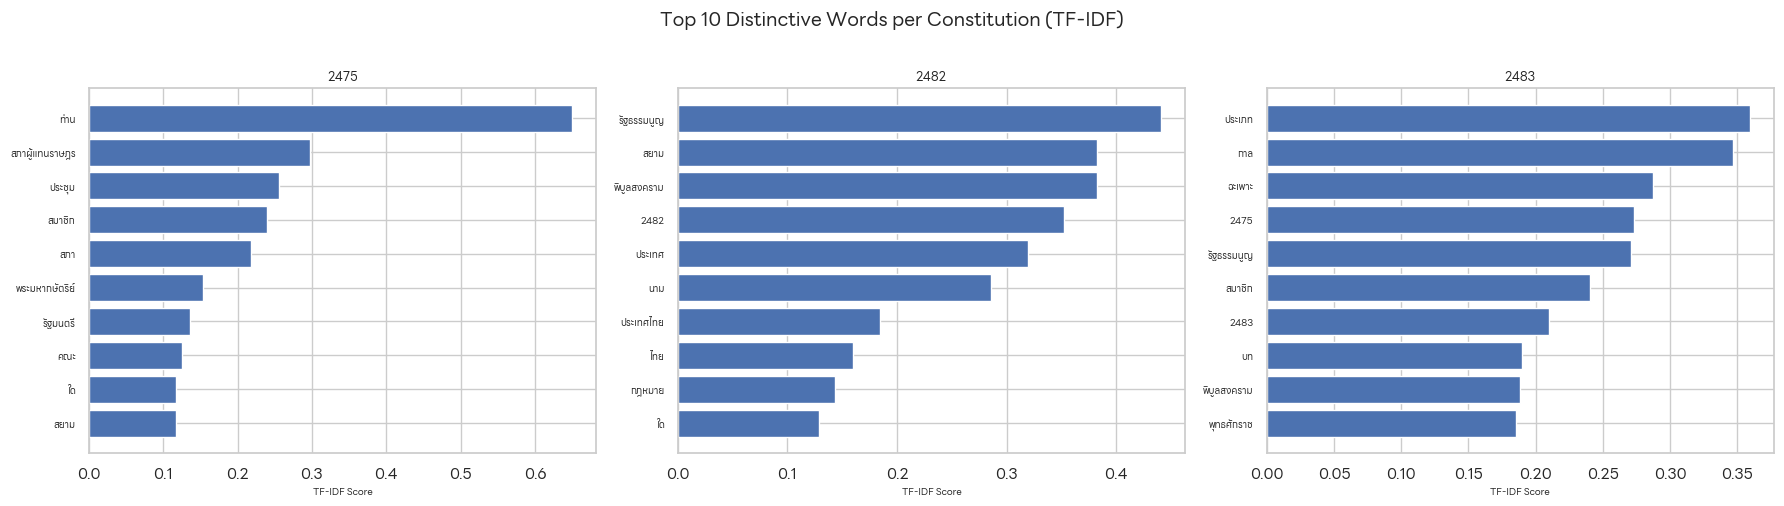

Total constitutions analysed: 38


In [26]:
# Per-constitution TF-IDF: find the most distinctive words for each constitution

df_tfidf_per = df.dropna(subset=['tokens']).copy()

# Build a document per constitution by joining all section tokens
const_docs = (
    df_tfidf_per.groupby('name_short')['tokens']
    .apply(lambda rows: [tok for toks in rows for tok in toks])
)

const_names = const_docs.index.tolist()

vectorizer_per = TfidfVectorizer(
    tokenizer=lambda x: x,
    preprocessor=lambda x: x,
    token_pattern=None,
    min_df=1
)
tfidf_per_matrix = vectorizer_per.fit_transform(const_docs)
feature_names_per = vectorizer_per.get_feature_names_out()

# For each constitution, show its top-N distinctive words
top_n = 10
per_const_top = {}
for idx, name in enumerate(const_names):
    row = np.asarray(tfidf_per_matrix[idx].todense()).flatten()
    top_indices = row.argsort()[-top_n:][::-1]
    per_const_top[name] = [(feature_names_per[i], row[i]) for i in top_indices]

# Plot a grid of bar charts (show first 12 constitutions for readability)
sample_names = const_names[:3]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for ax, name in zip(axes, sample_names, strict=False):
    words, scores = zip(*per_const_top[name], strict=False)
    ax.barh(list(words)[::-1], list(scores)[::-1])
    ax.set_title(name, fontsize=9)
    ax.tick_params(axis='y', labelsize=7)
    ax.set_xlabel('TF-IDF Score', fontsize=7)

plt.suptitle('Top 10 Distinctive Words per Constitution (TF-IDF)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f'Total constitutions analysed: {len(const_names)}')

In [27]:
def plot_per_const_tfidf(constitution):
    words, scores = zip(*per_const_top[constitution])
    top_df = pd.DataFrame({'Word': words, 'Score': scores})
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Score', y='Word', data=top_df)
    plt.title(f'Top {top_n} Distinctive Words — {constitution}')
    plt.show()

const_dropdown = widgets.Dropdown(
    options=const_names,
    description='Constitution:',
    layout=widgets.Layout(width='300px')
)
widgets.interactive(plot_per_const_tfidf, constitution=const_dropdown)

interactive(children=(Dropdown(description='Constitution:', layout=Layout(width='300px'), options=('2475', '24…

## 8. Timeline Analysis — Vocabulary & Length Over Constitutional History

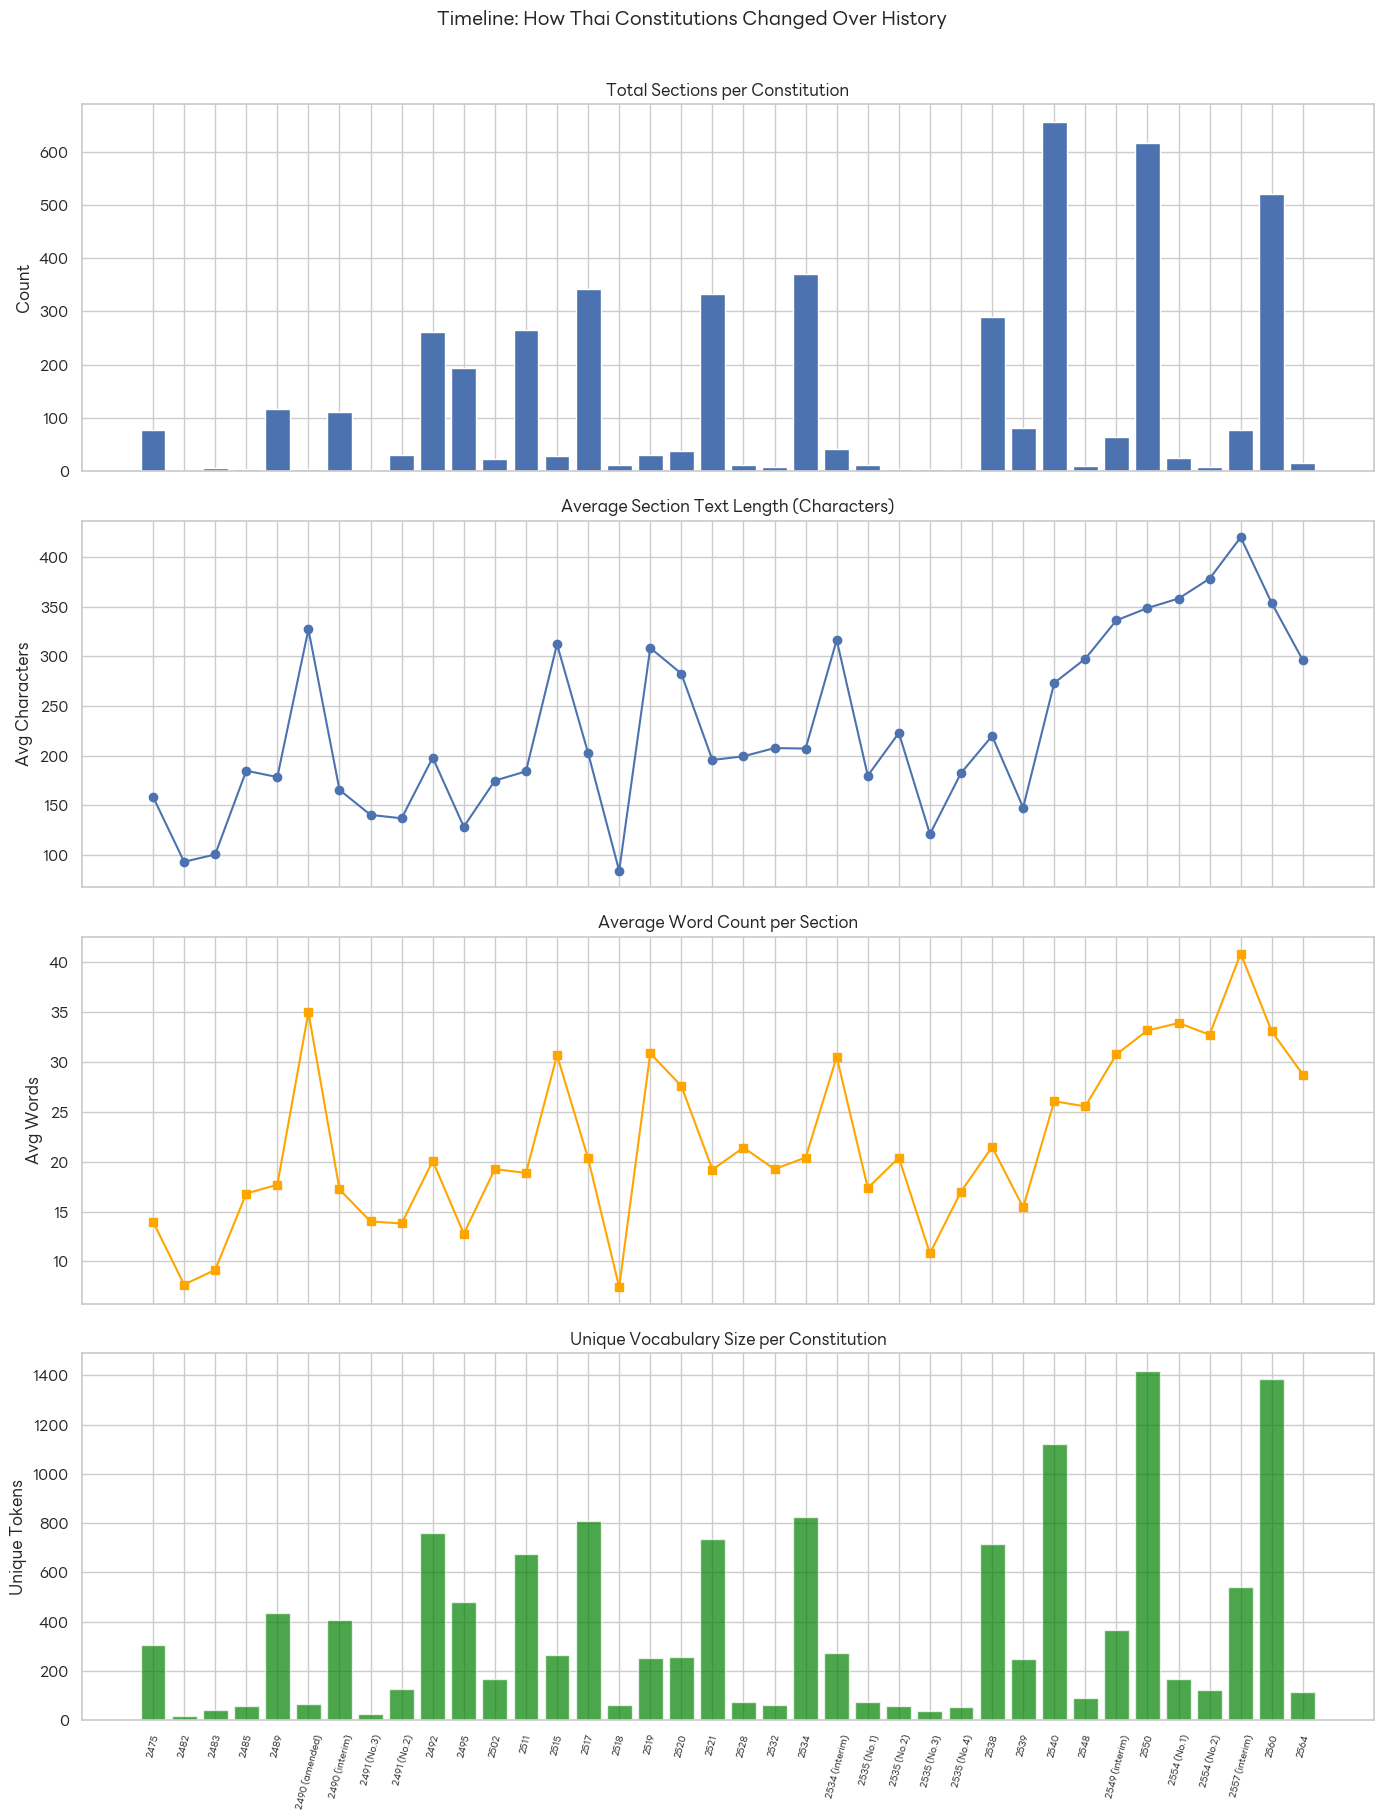

In [28]:
# Aggregate per-constitution metrics ordered by year
timeline_df = (
    df.dropna(subset=['tokens', 'text_length'])
    .groupby(['name_short', 'year_th'])
    .agg(
        total_sections=('text', 'count'),
        avg_text_length=('text_length', 'mean'),
        avg_word_count=('word_count', 'mean'),
        total_unique_words=('tokens', lambda x: len({tok for toks in x for tok in toks})),
        total_words=('tokens', lambda x: sum(len(toks) for toks in x)),
    )
    .reset_index()
    .sort_values('year_th')
)

fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True)

axes[0].bar(timeline_df['name_short'], timeline_df['total_sections'])
axes[0].set_title('Total Sections per Constitution')
axes[0].set_ylabel('Count')

axes[1].plot(timeline_df['name_short'], timeline_df['avg_text_length'], marker='o')
axes[1].set_title('Average Section Text Length (Characters)')
axes[1].set_ylabel('Avg Characters')

axes[2].plot(timeline_df['name_short'], timeline_df['avg_word_count'], marker='s', color='orange')
axes[2].set_title('Average Word Count per Section')
axes[2].set_ylabel('Avg Words')

axes[3].bar(timeline_df['name_short'], timeline_df['total_unique_words'], color='green', alpha=0.7)
axes[3].set_title('Unique Vocabulary Size per Constitution')
axes[3].set_ylabel('Unique Tokens')

for ax in axes:
    ax.tick_params(axis='x', rotation=75, labelsize=7)

plt.suptitle('Timeline: How Thai Constitutions Changed Over History', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

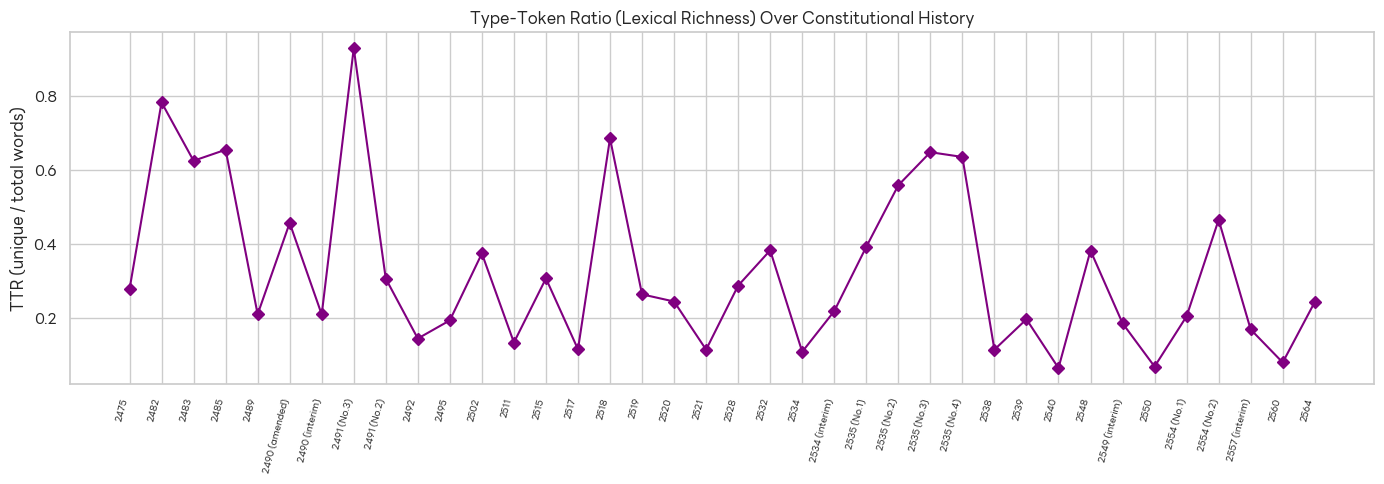

In [29]:
# Lexical richness over time: type-token ratio (unique / total words)
timeline_df['ttr'] = timeline_df['total_unique_words'] / timeline_df['total_words']

plt.figure(figsize=(14, 5))
plt.plot(timeline_df['name_short'], timeline_df['ttr'], marker='D', color='purple')
plt.title('Type-Token Ratio (Lexical Richness) Over Constitutional History')
plt.ylabel('TTR (unique / total words)')
plt.xticks(rotation=75, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

## 9. Cross-Constitution Similarity Heatmap

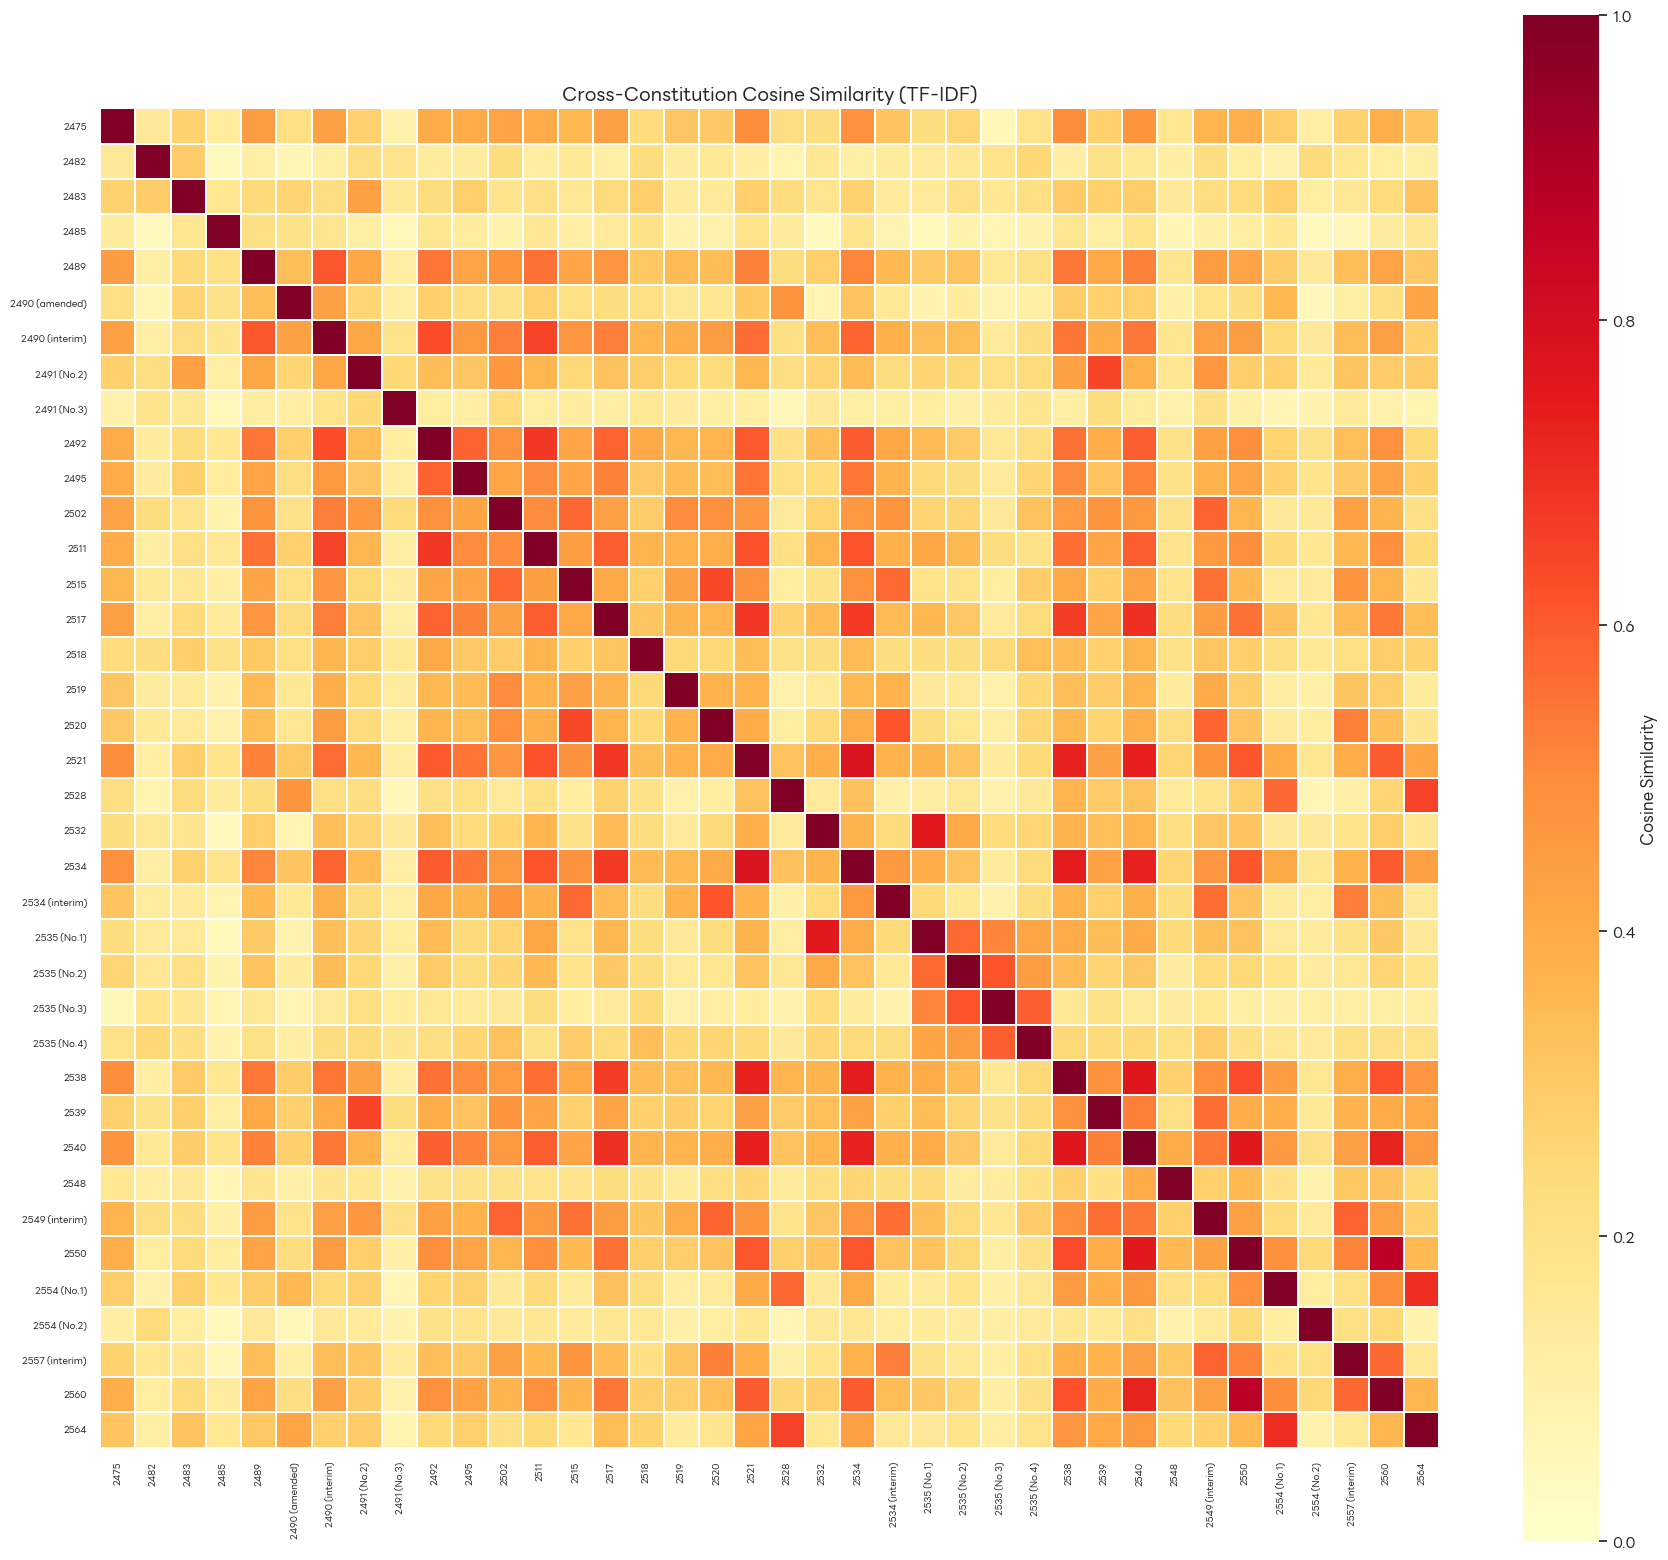

In [30]:
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(tfidf_per_matrix)
sim_df = pd.DataFrame(sim_matrix, index=const_names, columns=const_names)

# Full heatmap
plt.figure(figsize=(18, 16))
sns.heatmap(
    sim_df,
    cmap='YlOrRd',
    linewidths=0.3,
    square=True,
    xticklabels=True,
    yticklabels=True,
    cbar_kws={'label': 'Cosine Similarity'},
    vmin=0, vmax=1
)
plt.title('Cross-Constitution Cosine Similarity (TF-IDF)', fontsize=14)
plt.xticks(fontsize=7, rotation=90)
plt.yticks(fontsize=7, rotation=0)
plt.tight_layout()
plt.show()

In [31]:
# Most similar pairs (excluding self-similarity)
sim_pairs = []
for i in range(len(const_names)):
    for j in range(i + 1, len(const_names)):
        sim_pairs.append((const_names[i], const_names[j], sim_matrix[i, j]))

sim_pairs_df = pd.DataFrame(sim_pairs, columns=['Constitution A', 'Constitution B', 'Similarity'])
sim_pairs_df = sim_pairs_df.sort_values('Similarity', ascending=False)

print('Top 15 Most Similar Constitution Pairs:')
print(sim_pairs_df.head(15).to_string(index=False))

print('\nTop 10 Least Similar Constitution Pairs:')
print(sim_pairs_df.tail(10).to_string(index=False))

Top 15 Most Similar Constitution Pairs:
Constitution A Constitution B  Similarity
          2550           2560    0.872798
          2521           2534    0.783353
          2538           2540    0.762573
          2532    2535 (No.1)    0.757462
          2540           2550    0.753169
          2534           2538    0.744596
          2521           2540    0.738063
          2534           2540    0.731775
          2521           2538    0.730496
          2540           2560    0.729207
   2554 (No.1)           2564    0.701005
          2517           2540    0.696479
          2517           2521    0.677828
          2492           2511    0.676002
          2517           2534    0.672148

Top 10 Least Similar Constitution Pairs:
Constitution A Constitution B  Similarity
          2482 2490 (amended)    0.063236
          2475    2535 (No.3)    0.060820
          2485 2557 (interim)    0.058318
   2491 (No.3)           2528    0.057363
2490 (amended)    2554 (No.2)    0.0

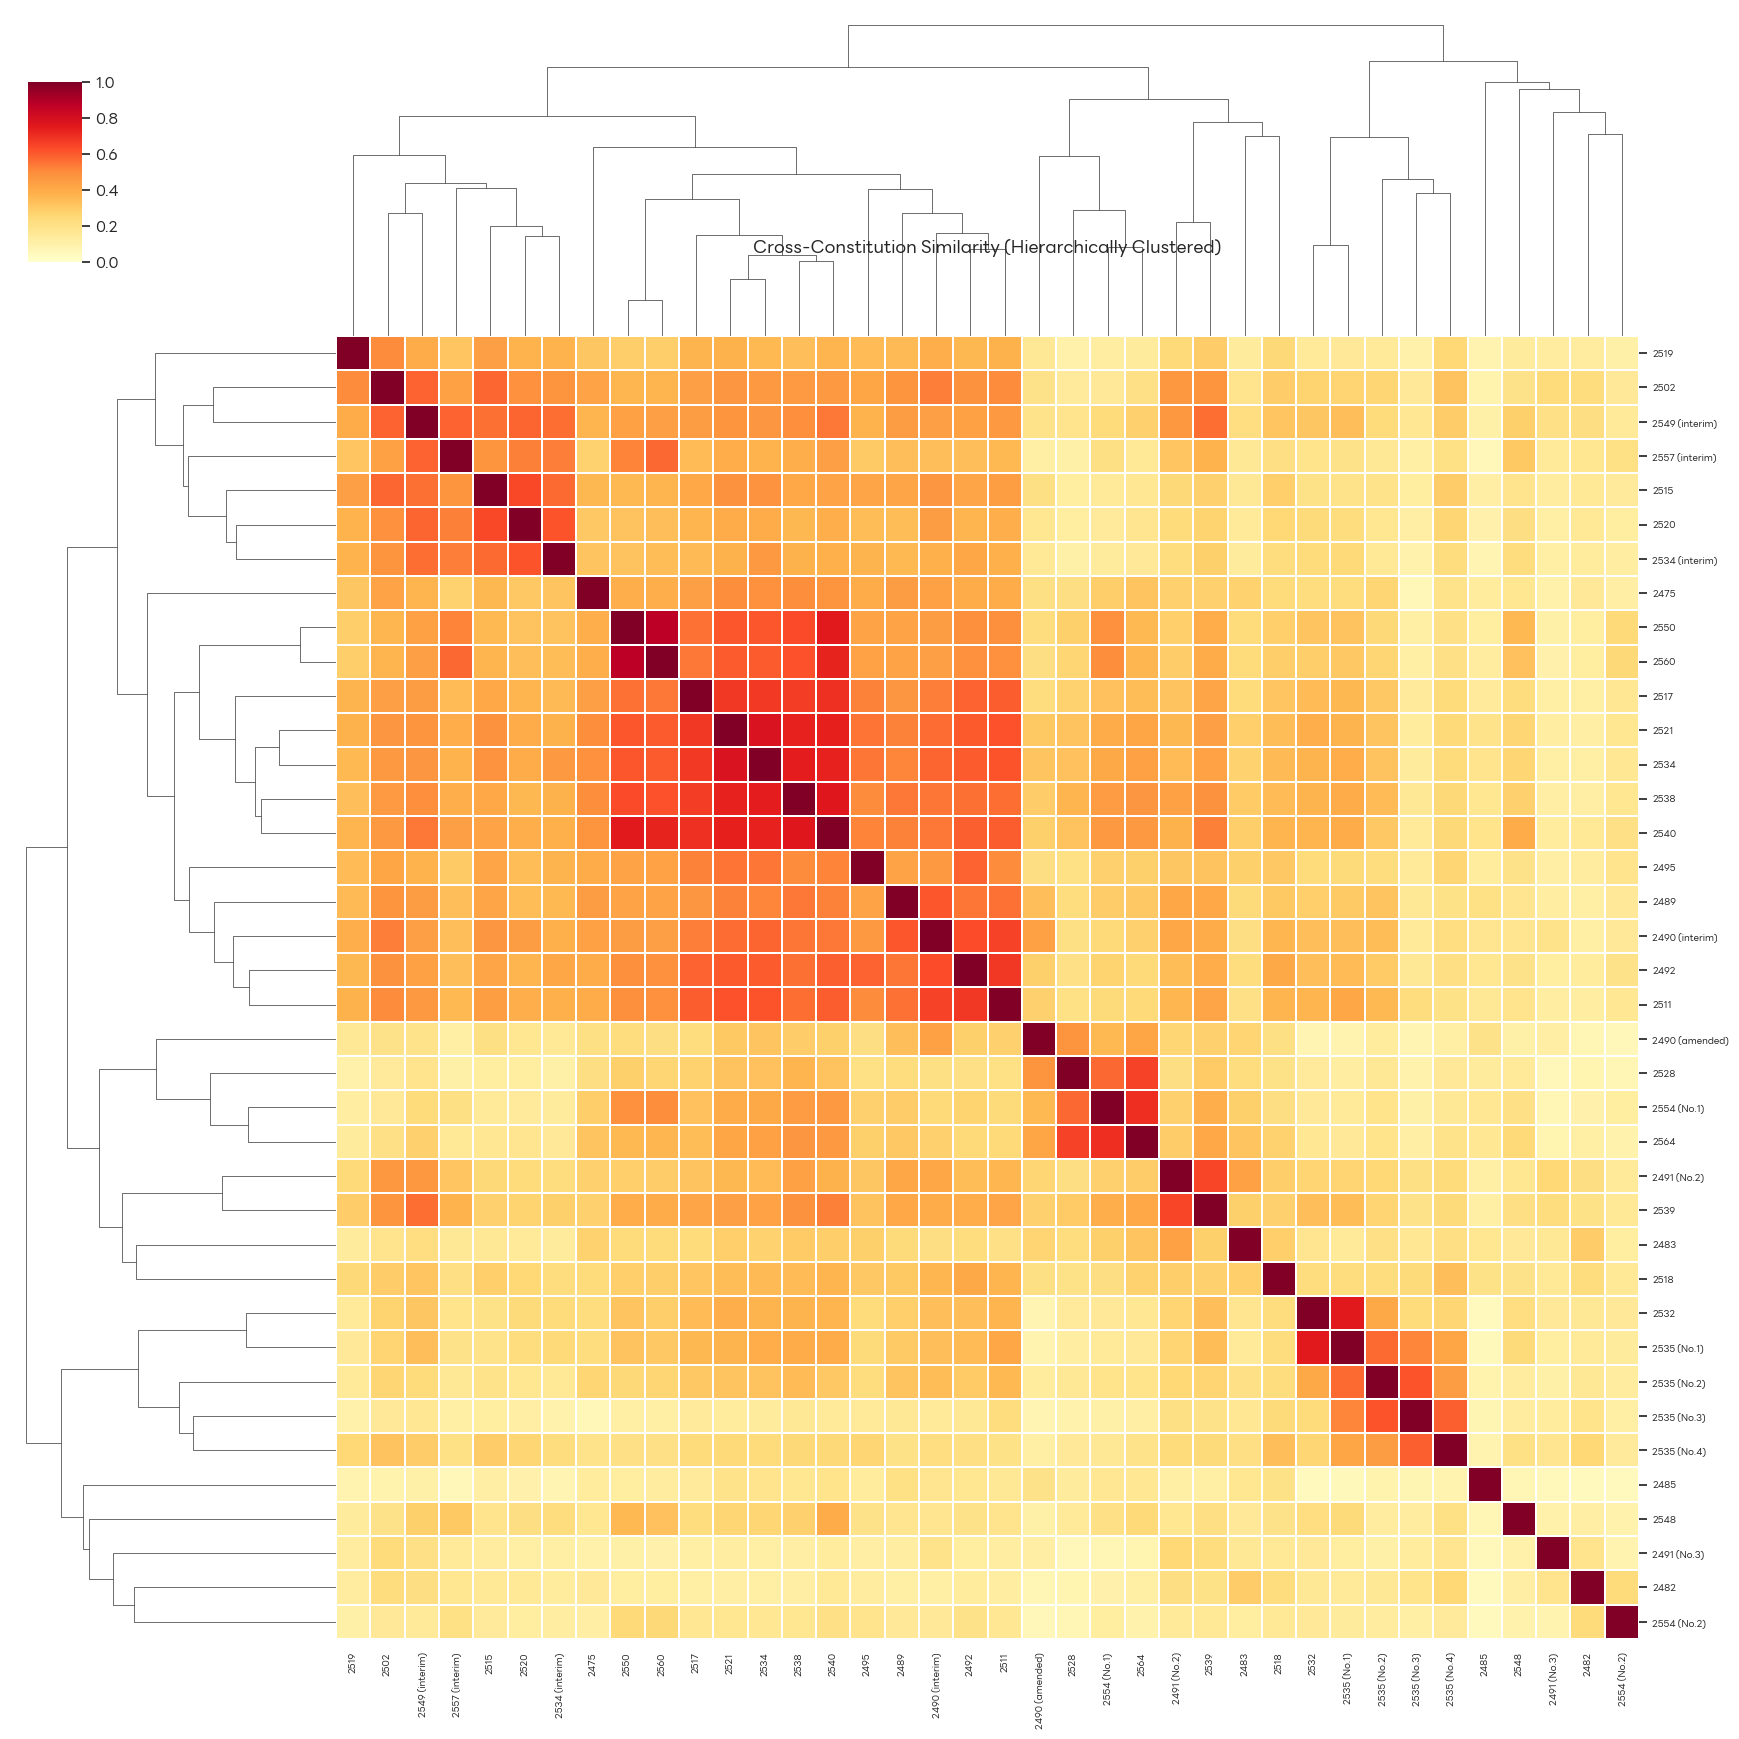

In [32]:
clustergrid = sns.clustermap(
    sim_df,
    cmap='YlOrRd',
    figsize=(18, 18),
    linewidths=0.2,
    xticklabels=True,
    yticklabels=True,
    vmin=0, vmax=1,
    cbar_pos=(0.02, 0.85, 0.03, 0.1),
    method='average'
)
clustergrid.ax_heatmap.set_title(
    'Cross-Constitution Similarity (Hierarchically Clustered)', fontsize=13, pad=60
)

plt.setp(clustergrid.ax_heatmap.get_xticklabels(), fontsize=7, rotation=90)
plt.setp(clustergrid.ax_heatmap.get_yticklabels(), fontsize=7, rotation=0)
plt.show()

## 10. Word Cloud Analysis

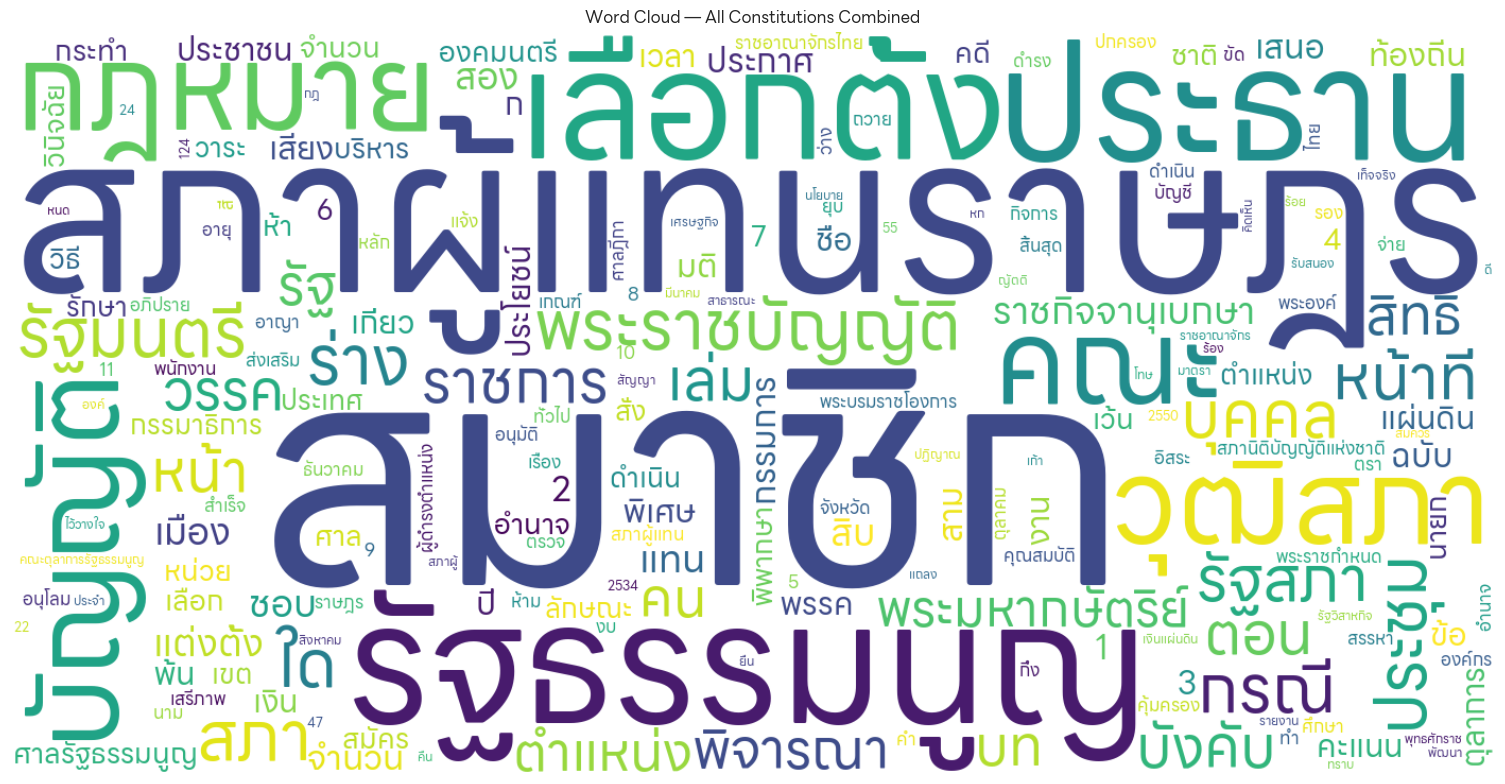

In [33]:
from wordcloud import WordCloud

# --- All-corpus word cloud ---
all_tokens_flat = [tok for toks in df['tokens'].dropna() for tok in toks]
all_freq = Counter(all_tokens_flat)

wc_all = WordCloud(
    font_path=font_path,
    width=1400,
    height=700,
    background_color='white',
    max_words=200,
    colormap='viridis',
    collocations=False,
).generate_from_frequencies(all_freq)

plt.figure(figsize=(16, 8))
plt.imshow(wc_all, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — All Constitutions Combined', fontsize=16, fontproperties=font_prop)
plt.tight_layout()
plt.show()

In [35]:
def plot_wordcloud(constitution):
    tokens_for_const = [
        tok
        for toks in df[df['name_short'] == constitution]['tokens'].dropna()
        for tok in toks
    ]
    freq = Counter(tokens_for_const)
    if not freq:
        print(f'No tokens found for {constitution}')
        return

    wc = WordCloud(
        font_path=font_path,
        width=1200,
        height=600,
        background_color='white',
        max_words=150,
        colormap='plasma',
        collocations=False,
    ).generate_from_frequencies(freq)

    plt.figure(figsize=(14, 7))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud — {constitution}', fontsize=14, fontproperties=font_prop)
    plt.tight_layout()
    plt.show()

wc_dropdown = widgets.Dropdown(
    options=const_names,
    description='Constitution:',
    layout=widgets.Layout(width='300px')
)
widgets.interactive(plot_wordcloud, constitution=wc_dropdown)

interactive(children=(Dropdown(description='Constitution:', layout=Layout(width='300px'), options=('2475', '24…